# Decision Tree Classification on the Iris Dataset

This notebook implements a Decision Tree classifier on the Iris dataset. Decision Trees work by asking a series of yes/no questions about the features to split the data into groups. Each split tries to make the groups as pure as possible (meaning each group has mostly one class).

This notebook is a supplementary implementation to satisfy the project requirement of implementing all three algorithms. The main comparison focus is KNN vs SVM.

## Step 1: Import Libraries

In [7]:
# Import the libraries we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools from sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

## Step 2: Load and Prepare the Data

Same Iris dataset and same split as the other notebooks.

In [8]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

# Split into training and testing (same split as other notebooks)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape[0], "samples")
print("Testing set:", X_test.shape[0], "samples")

Training set: 120 samples
Testing set: 30 samples


## Step 3: How Decision Trees Work

A Decision Tree makes predictions by splitting the data based on feature values. At each step, it picks the feature and the value that best separates the classes.

There are two common ways to measure how good a split is:
- **Gini impurity**: Measures how mixed the classes are in a group. A Gini of 0 means the group is pure (all one class).
- **Entropy**: Measures the amount of disorder. Lower entropy means a more pure group.

Both methods usually give similar results. We will test both and compare.

## Step 4: Train Decision Trees with Gini and Entropy

In [9]:
# Train a Decision Tree using Gini impurity
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dt_gini.fit(X_train, y_train)

# Make predictions
gini_predictions = dt_gini.predict(X_test)
gini_accuracy = accuracy_score(y_test, gini_predictions)

print("Decision Tree (Gini) Accuracy: {:.4f}".format(gini_accuracy))

Decision Tree (Gini) Accuracy: 1.0000


In [10]:
# Train a Decision Tree using Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt_entropy.fit(X_train, y_train)

# Make predictions
entropy_predictions = dt_entropy.predict(X_test)
entropy_accuracy = accuracy_score(y_test, entropy_predictions)

print("Decision Tree (Entropy) Accuracy: {:.4f}".format(entropy_accuracy))

Decision Tree (Entropy) Accuracy: 1.0000


In [11]:
# Compare the two
print("=== Comparison ===")
print("Gini accuracy:    {:.4f}".format(gini_accuracy))
print("Entropy accuracy: {:.4f}".format(entropy_accuracy))

if gini_accuracy >= entropy_accuracy:
    print("Winner: Gini (or tied)")
    best_dt = dt_gini
    best_criterion = 'Gini'
    best_predictions = gini_predictions
else:
    print("Winner: Entropy")
    best_dt = dt_entropy
    best_criterion = 'Entropy'
    best_predictions = entropy_predictions

=== Comparison ===
Gini accuracy:    1.0000
Entropy accuracy: 1.0000
Winner: Gini (or tied)


## Step 5: Visualize the Decision Tree

One of the biggest advantages of Decision Trees is that they are easy to understand. We can print the tree structure to see exactly what questions the model asks at each step.

In [12]:
# Print the tree as text
tree_text = export_text(best_dt, feature_names=list(iris.feature_names))
print("Decision Tree Structure ({}):\n".format(best_criterion))
print(tree_text)

Decision Tree Structure (Gini):

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



Each line in the tree shows a decision point. The model starts at the top and works its way down. At each step, it checks if a feature value is less than or equal to a threshold. When it reaches a leaf (the bottom), it makes a prediction based on which class has the most samples there.

## Step 6: Model Evaluation

In [13]:
# Calculate all metrics for the best model
accuracy = accuracy_score(y_test, best_predictions)
precision = precision_score(y_test, best_predictions, average='weighted')
recall = recall_score(y_test, best_predictions, average='weighted')
f1 = f1_score(y_test, best_predictions, average='weighted')

print("=== Decision Tree Results ({}) ===".format(best_criterion))
print()
print("Accuracy:  {:.4f}".format(accuracy))
print("Precision: {:.4f}".format(precision))
print("Recall:    {:.4f}".format(recall))
print("F1 Score:  {:.4f}".format(f1))

=== Decision Tree Results (Gini) ===

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


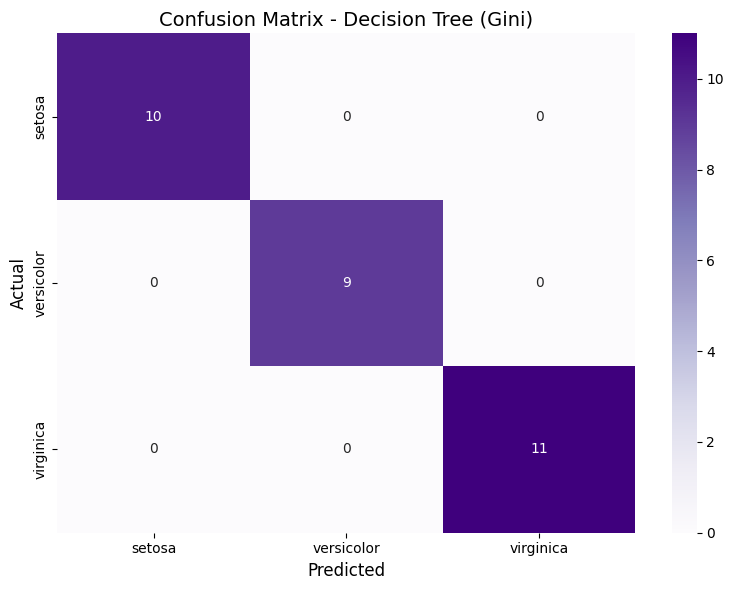

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Decision Tree ({})'.format(best_criterion), fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Classification report
print("Classification Report:")
print()
print(classification_report(y_test, best_predictions, target_names=iris.target_names))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 7: Feature Importance

Decision Trees can tell us which features were most useful for making predictions. This is called feature importance. A higher value means that feature was used more often and was more helpful in splitting the data.

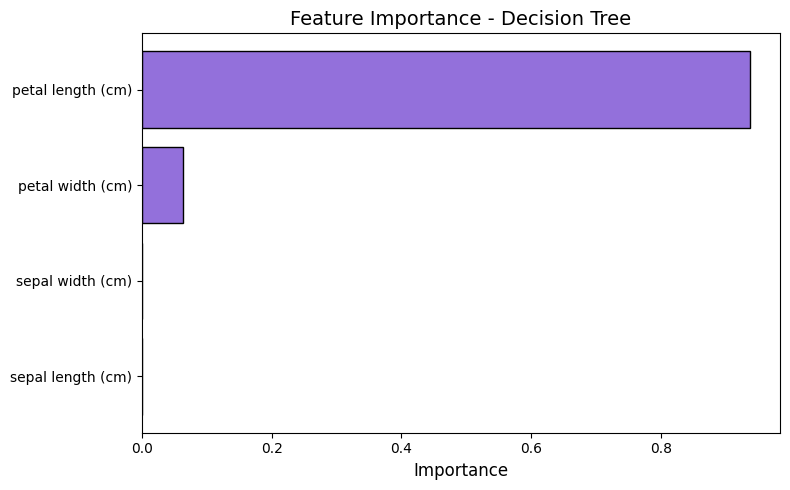

Feature Importance:
  petal length (cm): 0.9363
  petal width (cm): 0.0637
  sepal width (cm): 0.0000
  sepal length (cm): 0.0000


In [16]:
# Get feature importance
importances = best_dt.feature_importances_
feature_names = iris.feature_names

# Sort by importance
sorted_indices = np.argsort(importances)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(range(len(importances)), importances[sorted_indices], color='mediumpurple', edgecolor='black')
plt.yticks(range(len(importances)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Decision Tree', fontsize=14)
plt.tight_layout()
plt.show()

# Print the values
print("Feature Importance:")
for i in sorted_indices[::-1]:
    print("  {}: {:.4f}".format(feature_names[i], importances[i]))

## Summary

In this notebook we implemented a Decision Tree classifier on the Iris dataset:

1. Tested both Gini and Entropy split criteria
2. Visualized the tree structure to see what decisions the model makes
3. Evaluated with accuracy, precision, recall, F1, and confusion matrix
4. Looked at which features were most important for classification

Decision Trees are easy to interpret, which is their biggest strength. However, they can overfit if allowed to grow too deep. We used max_depth=4 to keep the tree manageable.

This notebook covers the project requirement of implementing all three algorithms (KNN, SVM, and Decision Tree). The main comparative analysis focuses on KNN vs SVM across the Iris and Diabetes datasets.